<a href="https://colab.research.google.com/github/kumargonuguntla/Projects/blob/main/Customer_Churn_Prediction_%26_Retention_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import pickle

In [7]:
# 2. CREATE SYNTHETIC TELECOM DATASET

np.random.seed(42)

data = pd.DataFrame({
    'tenure': np.random.randint(1, 72, 1000),
    'MonthlyCharges': np.random.uniform(20, 120, 1000),
    'TotalCharges': np.random.uniform(100, 8000, 1000),
    'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], 1000),
    'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], 1000),
    'TechSupport': np.random.choice(['Yes', 'No'], 1000),
    'OnlineSecurity': np.random.choice(['Yes', 'No'], 1000)
})

# Create target variable (Churn)
data['Churn'] = np.where(
    (data['Contract'] == 'Month-to-month') &
    (data['MonthlyCharges'] > 70) &
    (data['tenure'] < 12),
    1, 0
)

print("Dataset Preview:")
print(data.head())

Dataset Preview:
   tenure  MonthlyCharges  TotalCharges        Contract InternetService  \
0      52      105.569647   3271.805095        One year     Fiber optic   
1      15      103.021986   6420.560653  Month-to-month              No   
2      61       59.718353   1711.881514        One year     Fiber optic   
3      21       86.808514   4485.171099        Two year              No   
4      24       40.498430   5891.263239        One year             DSL   

  TechSupport OnlineSecurity  Churn  
0         Yes            Yes      0  
1          No            Yes      0  
2         Yes            Yes      0  
3          No             No      0  
4          No             No      0  



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tenure           1000 non-null   int64  
 1   MonthlyCharges   1000 non-null   float64
 2   TotalCharges     1000 non-null   float64
 3   Contract         1000 non-null   object 
 4   InternetService  1000 non-null   object 
 5   TechSupport      1000 non-null   object 
 6   OnlineSecurity   1000 non-null   object 
 7   Churn            1000 non-null   int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB
None


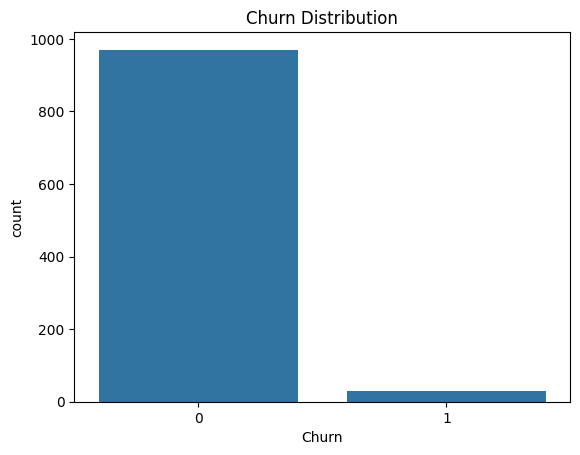

In [8]:
# 3. EDA

print("\nDataset Info:")
print(data.info())

plt.figure()
sns.countplot(x='Churn', data=data)
plt.title("Churn Distribution")
plt.show()


In [9]:
# 4. DATA PREPROCESSING

# Encode categorical variables
le = LabelEncoder()

for col in ['Contract', 'InternetService', 'TechSupport', 'OnlineSecurity']:
    data[col] = le.fit_transform(data[col])

X = data.drop('Churn', axis=1)
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [10]:
# 5. MODEL BUILDING

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

# Random Forest with tuning
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10]
}

grid = GridSearchCV(rf, param_grid, cv=3)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_


Logistic Regression Accuracy: 0.99

Random Forest Accuracy: 1.0

Classification Report (RF):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       194
           1       1.00      1.00      1.00         6

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



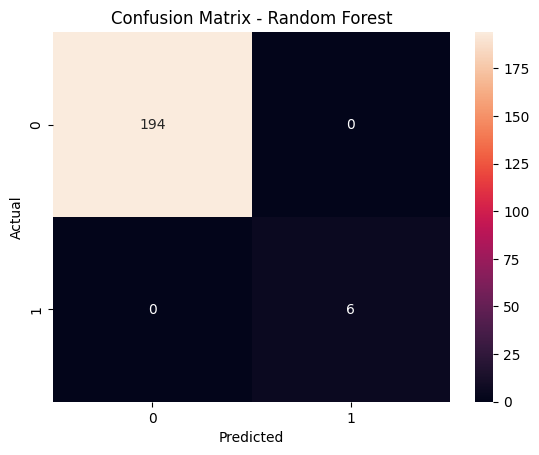

In [11]:
# 6. EVALUATION

# Logistic Regression
y_pred_lr = lr.predict(X_test_scaled)

# Random Forest
y_pred_rf = best_rf.predict(X_test)

print("\nLogistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nRandom Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report (RF):")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



Feature Importance:
           Feature  Importance
0           tenure    0.344874
1   MonthlyCharges    0.265876
3         Contract    0.213435
2     TotalCharges    0.124631
4  InternetService    0.021675
6   OnlineSecurity    0.016766
5      TechSupport    0.012743


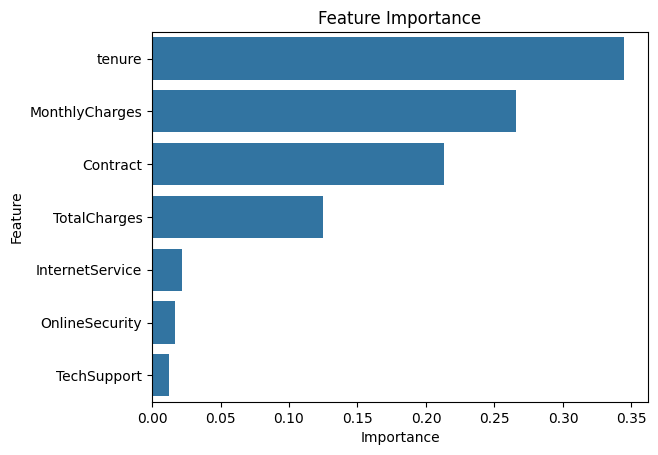

In [12]:
# 7. FEATURE IMPORTANCE (RF)

importance = best_rf.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(feat_imp)

plt.figure()
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title("Feature Importance")
plt.show()


In [13]:
# 8. SAVE MODEL & SCALER

pickle.dump(best_rf, open("churn_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("\nModel saved successfully!")


Model saved successfully!
